## Parte 01

Escolhemos o dataset DSB2018
Escolhemos o modelo ResUNet18


1. Treinem uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportem IoU
e Dice .
2. Extraiam instâncias pelo método ingênuo: limiar + componentes conexos.
3. Avaliem como instâncias. Atenção: o slide 6 define AP como precisão média sobre as classes — isso é
a métrica semântica. Vocês precisam generalizar para o nível de instância: para cada limiar de IoU
de 0,50 a 0,95 (passo 0,05), casar cada instância prevista com no máximo uma instância verdadeira,
contar TP/FP/FN, calcular AP, e tirar a média (mAP). Reportem também o erro absoluto de
contagem por imagem.
4. Documentem a regra de matching (guloso por IoU decrescente ou Hungarian). Regras diferentes dão
números diferentes — a escolha é de vocês, mas tem que estar explícita.
5. Quantifiquem o fracasso: gráfico do mAP (ou do erro de contagem) em função da densidade de
objetos na imagem. A tendência tem que ficar visível.


<!-- Datasets/DataLoaders (com cache em memória + disco)
Treino com BinaryCrossEntropy
Extração de instâncias (limiar + componentes conexos)
Avaliação de instâncias (mAP IoU 0.50:0.95)
Falha em função da densidade de objetos por imagem -->


#### Importações

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from scipy import ndimage
from pathlib import Path
import warnings
import time

#### Configurações

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
IOU_THRESHOLDS = np.arange(0.50, 1.00, 0.05)
PATH_TRAIN = Path('../data/stage1_train')
BATCH_SIZE = 16
IMG_SIZE = 256
print(f'Device: {DEVICE}')

Device: xpu


#### Classes e funções

In [3]:
class UNetBinary(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)
        self.pool = resnet.maxpool
        self.enc2 = resnet.layer1
        self.enc3 = resnet.layer2
        self.enc4 = resnet.layer3

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(nn.Conv2d(256, 128, kernel_size=3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(128, 64, kernel_size=3, padding=1), nn.ReLU())
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1)
        
    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(x2)
        x4 = self.enc4(x3)

        d3 = self.dec3(torch.cat([self.up3(x4), x3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), x2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), x1], dim=1))

        return self.final_conv(self.up0(d1))

class DSB2018Dataset(Dataset):
    def __init__(self, root, img_size=IMG_SIZE, augment=None,
                 cache_in_memory=True, cache_in_disk=True):
        self.root = Path(root)
        self.ids = sorted([p.name for p in self.root.iterdir() if p.is_dir()])
        self.img_size = img_size
        self.augment = augment
        self.cache_in_memory = cache_in_memory
        self.cache_in_disk = cache_in_disk
        self.memory_cache = {}

        if self.cache_in_memory and len(self.ids) > 1000:
            warnings.warn("Dataset grande (>1000 samples). O cache em memória pode esgotar a RAM.")

        # pré-computa os paths uma única vez, evita re-glob a cada __getitem__
        self.sample_paths = []
        for img_id in self.ids:
            sdir = self.root / img_id
            img_path = sdir / 'images' / f'{img_id}.png'
            mask_paths = sorted((sdir / 'masks').glob('*.png'))
            self.sample_paths.append((img_path, mask_paths, sdir))

    def __len__(self):
        return len(self.ids)

    def _disk_cache_path(self, sample_dir):
        # nome inclui img_size para não misturar caches de resoluções diferentes
        return sample_dir / f'cache_{self.img_size}.pt'

    def _process_from_disk(self, img_path, mask_paths):
        """Lê PNGs originais e faz resize. Sem augment (fica p/ __getitem__)."""
        image = cv.imread(str(img_path), cv.IMREAD_COLOR)
        image = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        image_r = cv.resize(image, (self.img_size, self.img_size),
                              interpolation=cv.INTER_LINEAR)

        instance_masks_r = []
        binary_mask_r = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        for mp in mask_paths:
            m = cv.imread(str(mp), cv.IMREAD_GRAYSCALE)
            m = cv.resize(m, (self.img_size, self.img_size), interpolation=cv.INTER_NEAREST)
            m = (m > 127).astype(np.uint8)
            instance_masks_r.append(m)
            binary_mask_r = np.maximum(binary_mask_r, m)

        return {
            'image': image_r,
            'mask': binary_mask_r,
            'instances': instance_masks_r,
        }

    def _get_cached_data(self, idx):
        if self.cache_in_memory and idx in self.memory_cache:
            return self.memory_cache[idx]

        img_path, mask_paths, sample_dir = self.sample_paths[idx]
        disk_cache_path = self._disk_cache_path(sample_dir)

        if self.cache_in_disk and disk_cache_path.exists():
            data = torch.load(disk_cache_path, weights_only=False)
        else:
            data = self._process_from_disk(img_path, mask_paths)
            if self.cache_in_disk:
                torch.save(data, disk_cache_path)

        if self.cache_in_memory:
            self.memory_cache[idx] = data

        return data

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        data = self._get_cached_data(idx)

        # copiar antes de augmentar, pra não corromper o que fica em cache
        image_r = data['image'].copy()
        binary_mask_r = data['mask'].copy()
        instance_masks_r = data['instances']

        if self.augment is not None:
            aug = self.augment(image=image_r, mask=binary_mask_r)
            image_r, binary_mask_r = aug['image'], aug['mask']

        image_t = torch.from_numpy(image_r / 255.0).permute(2, 0, 1).float()
        mask_t = torch.from_numpy(binary_mask_r.astype(np.float32)).unsqueeze(0)

        return image_t, mask_t, instance_masks_r, img_id


def split(n, p=0.2):
    n_val = int(p * n)
    n_train = n - n_val
    return [n_train, n_val]


def collate_fn(batch):
    images = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    instance_masks = [b[2] for b in batch]   # lista de listas (tam. variável)
    ids = [b[3] for b in batch]
    return images, masks, instance_masks, ids


# ---------------------------------------------------------------------------
# 1. Treino — BCE + Dice loss, e IoU/Dice como métricas semânticas
# ---------------------------------------------------------------------------

def bce_dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs_flat = probs.view(probs.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    inter = (probs_flat * targets_flat).sum(dim=1)
    union = probs_flat.sum(dim=1) + targets_flat.sum(dim=1)
    dice = (2 * inter + eps) / (union + eps)

    return F.binary_cross_entropy_with_logits(logits, targets) + (1 - dice.mean())

@torch.no_grad()
def compute_iou_dice(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - inter
    iou = (inter + eps) / (union + eps)
    dice = (2 * inter + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)
    return iou.sum(), dice.sum()


def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    history = {'train_loss': [], 'val_iou': [], 'val_dice': []}
    best_iou = -1

    for epoch in range(epochs):
        model.train()
        accumulated_loss = torch.tensor(0.0, device=DEVICE)

        for images, masks, _, _ in train_loader:
            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            logits = model(images)
            loss = bce_dice_loss(logits, masks)
            loss.backward()
            optimizer.step()
            accumulated_loss += loss.detach() * images.size(0)
        train_loss = accumulated_loss.item() / len(train_loader.dataset)

        
        model.eval()
        total_iou = torch.tensor(0.0, device=DEVICE)
        total_dice = torch.tensor(0.0, device=DEVICE)

        with torch.no_grad():
            for images, masks, _, _ in val_loader:
                images = images.to(DEVICE, non_blocking=True)
                masks = masks.to(DEVICE, non_blocking=True)
                logits = model(images)
                batch_iou, batch_dice = compute_iou_dice(logits, masks)
                total_iou += batch_iou
                total_dice += batch_dice

        val_iou = total_iou.item() / len(val_loader.dataset)
        val_dice = total_dice.item() / len(val_loader.dataset)
        scheduler.step(val_iou)

        history['train_loss'].append(train_loss)
        history['val_iou'].append(val_iou)
        history['val_dice'].append(val_dice)
        print(f'Epoch {epoch+1}/{epochs} | Loss: {train_loss:.4f} | IoU: {val_iou:.4f} | Dice: {val_dice:.4f}')

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), 'best_model.pt')

    return history


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'])
    axes[0].set_title('Loss de treino (BCE + Dice)')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['val_iou'], label='IoU')
    axes[1].plot(history['val_dice'], label='Dice')
    axes[1].set_title('Métricas de validação (nível de pixel)')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# 2. Extração de instâncias ingênua: limiar + componentes conexos
# ---------------------------------------------------------------------------


def extract_instances(prob_map, threshold=0.5, min_size=5):
    """
    prob_map: array HxW de probabilidades (saída do sigmoid).
    Retorna lista de máscaras binárias HxW, uma por componente conexa
    (conectividade 8, via scipy.ndimage.label), descartando ruído < min_size px.
    """
    binary = (prob_map > threshold).astype(np.uint8)
    structure = np.ones((3, 3), dtype=np.uint8)  # conectividade-8
    labeled, num = ndimage.label(binary, structure=structure)
    instances = []
    for i in range(1, num + 1):
        inst_mask = (labeled == i).astype(np.uint8)
        if inst_mask.sum() >= min_size:
            instances.append(inst_mask)
    return instances


# ---------------------------------------------------------------------------
# 3 e 4. Avaliação como instâncias — matching guloso por IoU decrescente
# ---------------------------------------------------------------------------
#
# REGRA DE MATCHING (documentada, escolha do grupo): guloso por IoU decrescente.
#   1. Calcula a matriz de IoU (pred x gt) entre todas as máscaras preditas
#      e todas as máscaras verdadeiras da imagem.
#   2. Lista todos os pares (pred, gt) com seu IoU e ordena por IoU decrescente.
#   3. Percorre a lista em ordem; casa o par se IoU >= limiar do momento E se
#      nem a predição nem o GT já foram usados em outro casamento.
#   4. Predições não casadas => FP. GTs não casados => FN. Pares casados => TP.
#      Cada instância prevista casa com NO MÁXIMO uma verdadeira, e vice-versa.
#
# (Alternativa seria o algoritmo Hungarian/linear_sum_assignment, que resolve
#  o casamento ótimo global em vez de guloso; optamos pelo guloso por ser o
#  padrão adotado na métrica oficial do próprio DSB2018 e por não exigir
#  matriz de custo quadrada/completa.)

# AP por limiar: como o método ingênuo (limiar + componentes conexos) não
# produz um score de confiança por instância, não há curva precisão-recall
# para integrar. Seguimos a métrica oficial do DSB2018: em cada limiar de
# IoU, AP = TP / (TP + FP + FN), agregado sobre TODAS as imagens do split.
# mAP = média de AP sobre os limiares 0.50:0.95:0.05.


@torch.no_grad()
def evaluate_instances(model, loader, prob_threshold=0.5, min_size=5, k_samples=6):
    model.eval()

    n_threshold = len(IOU_THRESHOLDS)
    tp_total = np.zeros(n_threshold)
    denom_total = np.zeros(n_threshold)

    count_errors = []
    densities = []
    per_image_aps = []
    samples = []

    for images, _, instance_masks_batch, _ in loader:
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()

        for b in range(images.size(0)):
            pred_masks = extract_instances(probs[b, 0], prob_threshold, min_size)
            gt_masks = instance_masks_batch[b]
            n_pred, n_gt = len(pred_masks), len(gt_masks)
            count_error = abs(n_pred - n_gt)
            count_errors.append(count_error)
            densities.append(n_gt)

            img_plot = images[b].cpu().numpy().transpose(1, 2, 0)
            samples.append((count_error, img_plot, gt_masks, pred_masks))

            if n_pred == 0 and n_gt == 0:
                per_image_aps.append(1.0)
                continue 

            if n_pred == 0 or n_gt == 0:
                denom_total += n_pred + n_gt
                per_image_aps.append(0.0)
                continue

            pairs = []
            img_aps = np.zeros(n_threshold)


            pred_flat = np.array(pred_masks, dtype=np.int32).reshape(n_pred, -1)
            gt_flat = np.array(gt_masks, dtype=np.int32).reshape(n_gt, -1)
            inter_matrix = np.dot(pred_flat, gt_flat.T)
            area_pred = pred_flat.sum(axis=1)[:, np.newaxis]
            area_gt = gt_flat.sum(axis=1)[np.newaxis, :]
            union_matrix = area_pred + area_gt - inter_matrix
            iou_matrix = inter_matrix / np.maximum(union_matrix, 1e-6)
            pairs = [(iou_matrix[i, j], i, j) 
                    for i in range(n_pred) for j in range(n_gt) 
                    if iou_matrix[i, j] > 0
            ]
            pairs.sort(key=lambda x: -x[0])

            for k, t in enumerate(IOU_THRESHOLDS):
                matched_pred, matched_gt = set(), set()
                tp = 0
                for iou, i, j in pairs:
                    if iou < t:
                        break
                    if i not in matched_pred and j not in matched_gt:
                        matched_pred.add(i)
                        matched_gt.add(j)
                        tp += 1
                fp = n_pred - tp
                fn = n_gt - tp
                denom = tp + fp + fn
                img_aps[k] = tp / denom if denom > 0 else 1.0

                tp_total[k] += tp
                denom_total[k] += denom

            per_image_aps.append(float(img_aps.mean()))

    aps = np.where(denom_total > 0, tp_total / denom_total, 1.0)
    mAP = np.mean(aps)
    samples.sort(key=lambda s: -s[0])
    return mAP, aps, count_errors, densities, per_image_aps, samples[:k_samples]


# ---------------------------------------------------------------------------
# 5. Fracasso em função da densidade de objetos por imagem
# ---------------------------------------------------------------------------


def plot_metrics(all_mAPs, all_count_errors, all_densities):
    print(f"Média global mAP: {np.mean(all_mAPs):.4f}")
    print(f"Média global Erro Absoluto de Contagem: {np.mean(all_count_errors):.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 6))

    color = 'tab:blue'
    ax[0].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[0].set_ylabel('mAP (Threshold 0.5 a 0.95)', color=color)
    ax[0].scatter(all_densities, all_mAPs, color=color, alpha=0.6, label='mAP')
    ax[0].tick_params(axis='y', labelcolor=color)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['top'].set_visible(False)
    ax[0].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize=10, fontweight='bold')

    color = 'tab:red'
    ax[1].set_ylabel('Erro Absoluto de Contagem', color=color)
    ax[1].scatter(all_densities, all_count_errors, color=color, alpha=0.6, label='Erro de Contagem')
    ax[1].set_xlabel('Densidade de Objetos (Qtd. de Instâncias Reais)')
    ax[1].tick_params(axis='y', labelcolor=color)
    ax[1].spines['right'].set_visible(False)
    ax[1].spines['top'].set_visible(False)
    ax[1].set_title("Quantificação de Falhas: Desempenho vs. Densidade", fontsize=10, fontweight='bold')
    plt.grid(False)
    fig.tight_layout()
    plt.show()

    
def plot_density_failure(densities, count_errors, per_image_aps, n_bins=6):
    """
    Gráfico de dispersão bruto (cinza, transparente) + curva de médias por
    faixa de densidade (destacada), pra tendência ficar visível mesmo com
    ruído entre imagens individuais. Se `per_image_aps` for passado, plota
    um segundo painel com mAP-por-imagem vs. densidade.
    """
    densities = np.asarray(densities)
    count_errors = np.asarray(count_errors)
    per_image_aps = np.asarray(per_image_aps)

    # bins por quantil: aprox. mesmo número de imagens por faixa
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(densities, quantiles))
    bin_idx = np.digitize(densities, edges[1:-1], right=True)
    n_bins_eff = len(edges) - 1

    bin_density = [densities[bin_idx == k].mean() for k in range(n_bins_eff)]
    bin_error = [count_errors[bin_idx == k].mean() for k in range(n_bins_eff)]

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    bin_ap = [per_image_aps[bin_idx == k].mean() for k in range(n_bins_eff)]
    axes[0].scatter(densities, per_image_aps, alpha=0.25, color='gray',
                        label='imagens individuais')
    axes[0].plot(bin_density, bin_ap, marker='o', color='steelblue',
                    linewidth=2, label='média por faixa')
    axes[0].set_xlabel('Nº de núcleos (densidade, ground truth)')
    axes[0].set_ylabel('mAP da imagem (0.50:0.95)')
    axes[0].set_title('mAP vs. densidade de objetos')
    axes[0].legend()
    
    axes[1].scatter(densities, count_errors, alpha=0.25, color='gray',
                     label='imagens individuais')
    axes[1].plot(bin_density, bin_error, marker='o', color='tomato',
                 linewidth=2, label='média por faixa')
    axes[1].set_xlabel('Nº de núcleos (densidade, ground truth)')
    axes[1].set_ylabel('Erro absoluto de contagem')
    axes[1].set_title('Erro de contagem vs. densidade de objetos')
    axes[1].legend()

    
    plt.tight_layout()
    plt.show()


    corr_ap = np.corrcoef(densities, per_image_aps)[0, 1]
    print(f'Correlação (densidade x mAP por imagem): {corr_ap:.3f}')

    corr_err = np.corrcoef(densities, count_errors)[0, 1]
    print(f'Correlação (densidade x erro de contagem): {corr_err:.3f}')



def masks_to_label(masks, shape):
    """
    Converte uma LISTA de máscaras binárias (formato usado por
    evaluate_instances/greedy_match) num único MAPA DE RÓTULOS (H,W),
    formato que cmap='nipy_spectral' espera pra colorir por instância:
    0 = fundo, 1 = instância 1, 2 = instância 2, ...
 
    Se duas máscaras se sobrepuserem (não deveria acontecer com
    componentes conexos, mas por segurança), a última da lista "ganha"
    o pixel disputado.
    """
    label = np.zeros(shape, dtype=np.int32)
    for i, m in enumerate(masks, start=1):
        label[m.astype(bool)] = i
    return label

    
def plot_samples(samples, part: int = 1):
    """
    Layout: uma coluna por amostra, 3 linhas (original / gabarito / predição),
    cada instância com uma cor distinta via nipy_spectral (fundo forçado a
    preto com máscara, pra não ficar colorido também).
    """
    n_samples = len(samples)
    fig, axes = plt.subplots(3, n_samples, figsize=(4 * n_samples, 12), squeeze=False)
    fig.suptitle(f"Amostra de {n_samples} Resultados - Parte {part}", fontsize=14, fontweight='bold')
 
    cmap = plt.get_cmap('prism').copy()
    cmap.set_bad('black')  # fundo (rótulo 0, mascarado) sempre preto
 
    for idx, (err, img, gt_masks, pred_masks) in enumerate(samples):
        H, W = img.shape[:2]
        gt_label = masks_to_label(gt_masks, (H, W))
        pred_label = masks_to_label(pred_masks, (H, W))
 
        gt_masked = np.ma.masked_where(gt_label == 0, gt_label)
        pred_masked = np.ma.masked_where(pred_label == 0, pred_label)

        axes[0, idx].imshow(img)
        axes[0, idx].set_title("Original")
        axes[0, idx].axis('off')

        axes[1, idx].imshow(gt_masked, cmap=cmap, interpolation='nearest')
        axes[1, idx].set_title(f"Gabarito (Instâncias: {len(gt_masks)})")
        axes[1, idx].axis('off')
 
        axes[2, idx].imshow(pred_masked, cmap=cmap, interpolation='nearest')
        axes[2, idx].set_title(f"Predição (Instâncias: {len(pred_masks)}) | Erro: {err}")
        axes[2, idx].axis('off')
 
    plt.tight_layout()
    plt.show()

#### Inicialização

In [4]:
model = UNetBinary().to(DEVICE)
full_ds = DSB2018Dataset(PATH_TRAIN)
train_ds, val_ds = random_split(full_ds, split(len(full_ds)), generator=torch.Generator().manual_seed(42))
print(f'Train: {len(train_ds)} amostras | Val: {len(val_ds)} amostras')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, pin_memory=True)


Train: 536 amostras | Val: 134 amostras


#### Treinamento


Epoch 1/10 | Loss: 1.4964 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 1.0188 | IoU: 0.4855 | Dice: 0.6248
Epoch 3/10 | Loss: 0.5488 | IoU: 0.7000 | Dice: 0.8149
Epoch 4/10 | Loss: 0.3470 | IoU: 0.7394 | Dice: 0.8422
Epoch 5/10 | Loss: 0.2900 | IoU: 0.7537 | Dice: 0.8523
Epoch 6/10 | Loss: 0.2653 | IoU: 0.7726 | Dice: 0.8651
Epoch 7/10 | Loss: 0.2549 | IoU: 0.7700 | Dice: 0.8636
Epoch 8/10 | Loss: 0.2341 | IoU: 0.7926 | Dice: 0.8781
Epoch 9/10 | Loss: 0.2285 | IoU: 0.7932 | Dice: 0.8787
Epoch 10/10 | Loss: 0.2238 | IoU: 0.7983 | Dice: 0.8820
Tempo de treinamento: 3.77 minutos
Melhor IoU (val): 0.7983
Dice corresp.: 0.8820


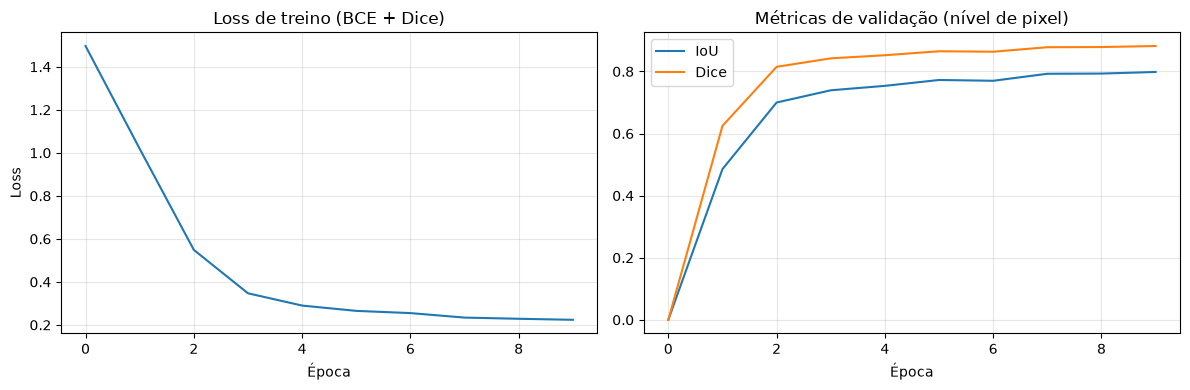

In [5]:
start = time.time()
history = train_model(model, train_loader, val_loader)
print(f"Tempo de treinamento: {(time.time() - start)/60:.2f} minutos")
print(f"Melhor IoU (val): {max(history['val_iou']):.4f}")
print(f"Dice corresp.: {history['val_dice'][-1]:.4f}")
plot_training_curves(history)

#### Validação e plotagem

In [6]:
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE, weights_only=True))

mAP, aps, count_errors, densities, per_image_aps, samples = evaluate_instances(
    model, val_loader, prob_threshold=0.5, min_size=5, k_samples=6)
print(f'mAP (IoU 0.50:0.95): {mAP:.4f}')


mAP (IoU 0.50:0.95): 0.2537


Média global mAP: 0.3723
Média global Erro Absoluto de Contagem: 19.3507


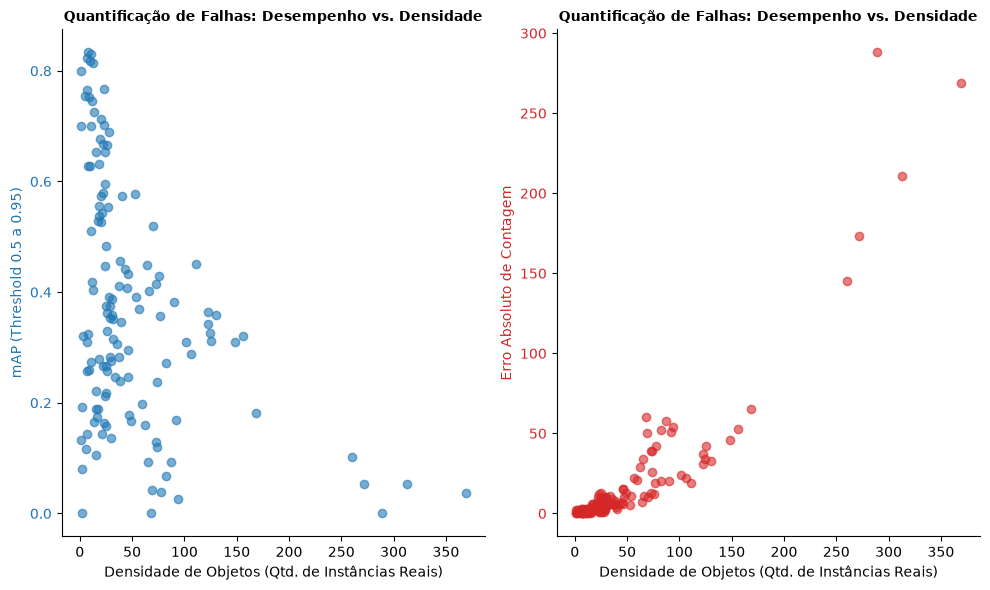

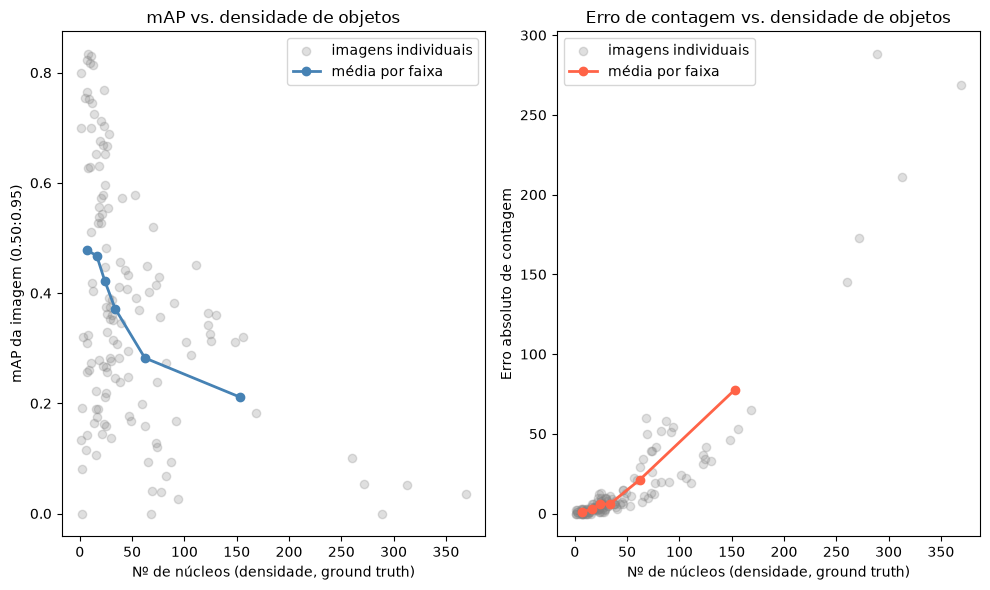

Correlação (densidade x mAP por imagem): -0.411
Correlação (densidade x erro de contagem): 0.920


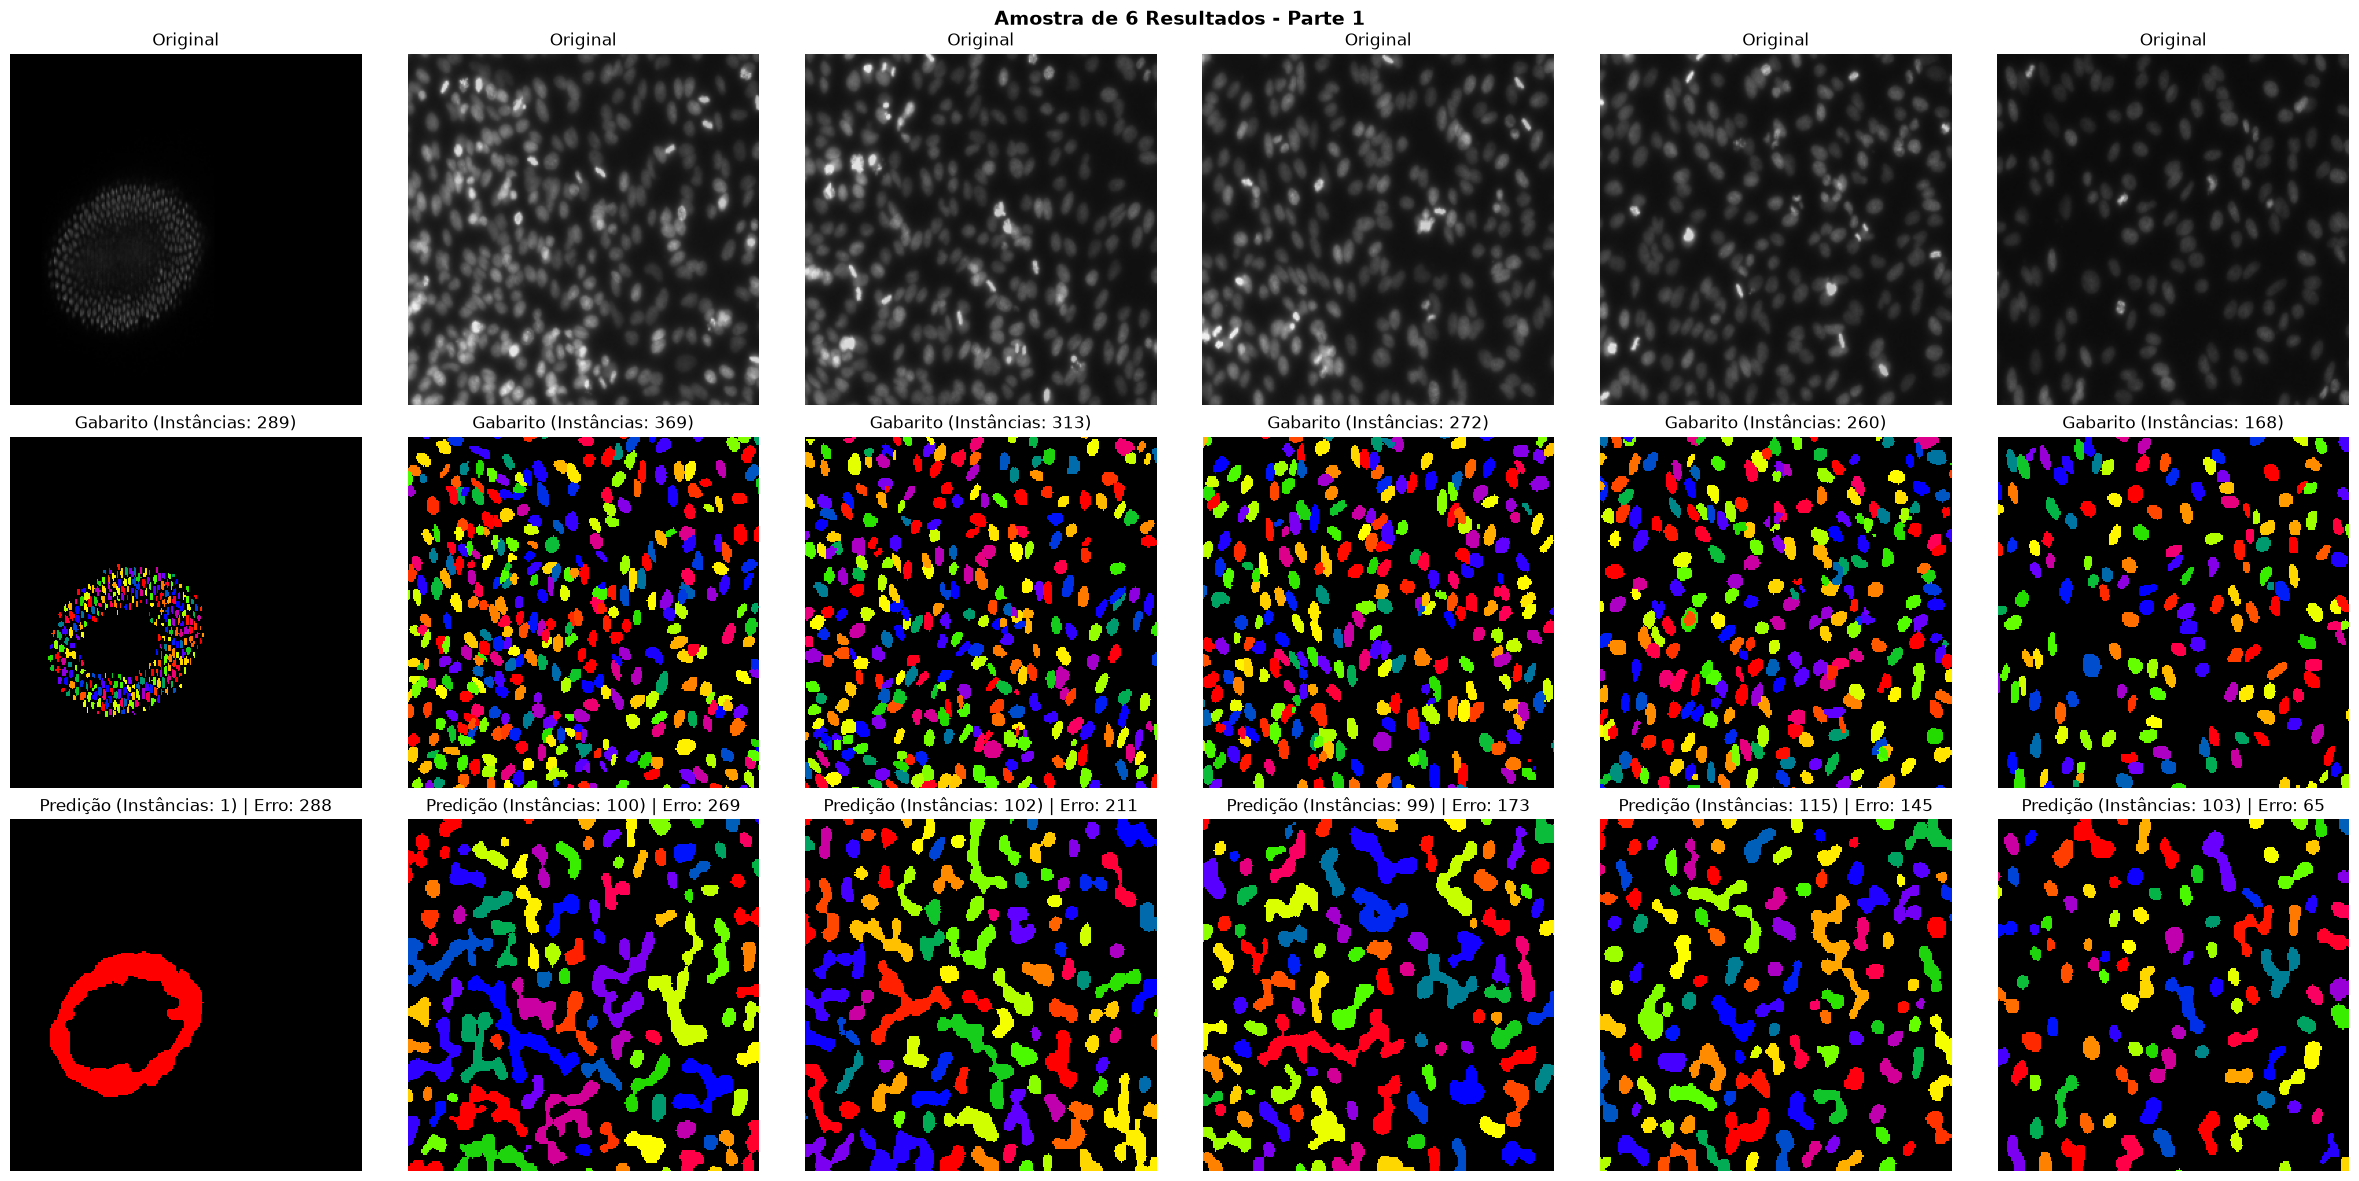

In [7]:
plot_metrics(per_image_aps, count_errors, densities)
plot_density_failure(densities, count_errors, per_image_aps)
plot_samples(samples)